In [50]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

In [51]:
DATA_PATH = Path("record2.parsed.json")
LABELED_PATH = Path("record2.labeled.json")
T = 0
FPS = 10
LABEL_INTERVALS = [
    # (0.0, 1.8, "standing"),
    # (1.8, 3.2, "sitting"),
    # (3.2, 4.0, "standing_up"),
]

In [52]:
def load_frames(path):
    return json.loads(path.read_text())["frames"]

In [53]:
frames = load_frames(DATA_PATH)
print(len(frames), frames[0]["frame_number"], frames[-1]["frame_number"])

1000 12917 13916


In [54]:
def get_frame(frames, t):
    return frames[t]

In [55]:
frame = get_frame(frames, T)
print(frame["frame_number"], len(frame["points"]))

12917 7


In [56]:
def get_feature_values(frame, key):
    return [point[key] for point in frame["points"]]

In [57]:
print(frame["points"][0])

{'x': -0.002709, 'y': 0.072259, 'z': -0.048757, 'velocity': 0.0, 'snr': 362, 'noise': 495}


In [58]:
def get_feature_time_values(frames, key, fps):
    times = []
    values = []
    for index, frame in enumerate(frames):
        time = index / fps
        for point in frame["points"]:
            times.append(time)
            values.append(point[key])
    return times, values

In [59]:
def get_frame_times(frames, fps):
    return [index / fps for index in range(len(frames))]

In [60]:
def get_feature_means(frames, key):
    return [sum(point[key] for point in frame["points"]) / len(frame["points"]) for frame in frames]

In [61]:
def get_point_counts(frames):
    return [len(frame["points"]) for frame in frames]

In [62]:
def plot_feature_time(frames, fps, t):
    frame_times = get_frame_times(frames, fps)
    point_counts = get_point_counts(frames)
    selected_time = t / fps
    feature_names = ["x", "y", "z", "velocity", "snr", "noise"]
    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    for axis, key in zip(axes.flat[:6], feature_names):
        times, values = get_feature_time_values(frames, key, fps)
        axis.scatter(times, values, s=8, alpha=0.35)
        axis.axvline(selected_time, color="red")
        axis.set_title(f"{key} over time")
        axis.set_ylabel(key)
    axes[3, 0].plot(frame_times, point_counts)
    axes[3, 0].axvline(selected_time, color="red")
    axes[3, 0].set_title("point count over time")
    axes[3, 0].set_ylabel("count")
    axes[3, 1].axis("off")
    axes[3, 0].set_xlabel("time (s)")
    axes[2, 0].set_xlabel("time (s)")
    axes[2, 1].set_xlabel("time (s)")
    fig.tight_layout()

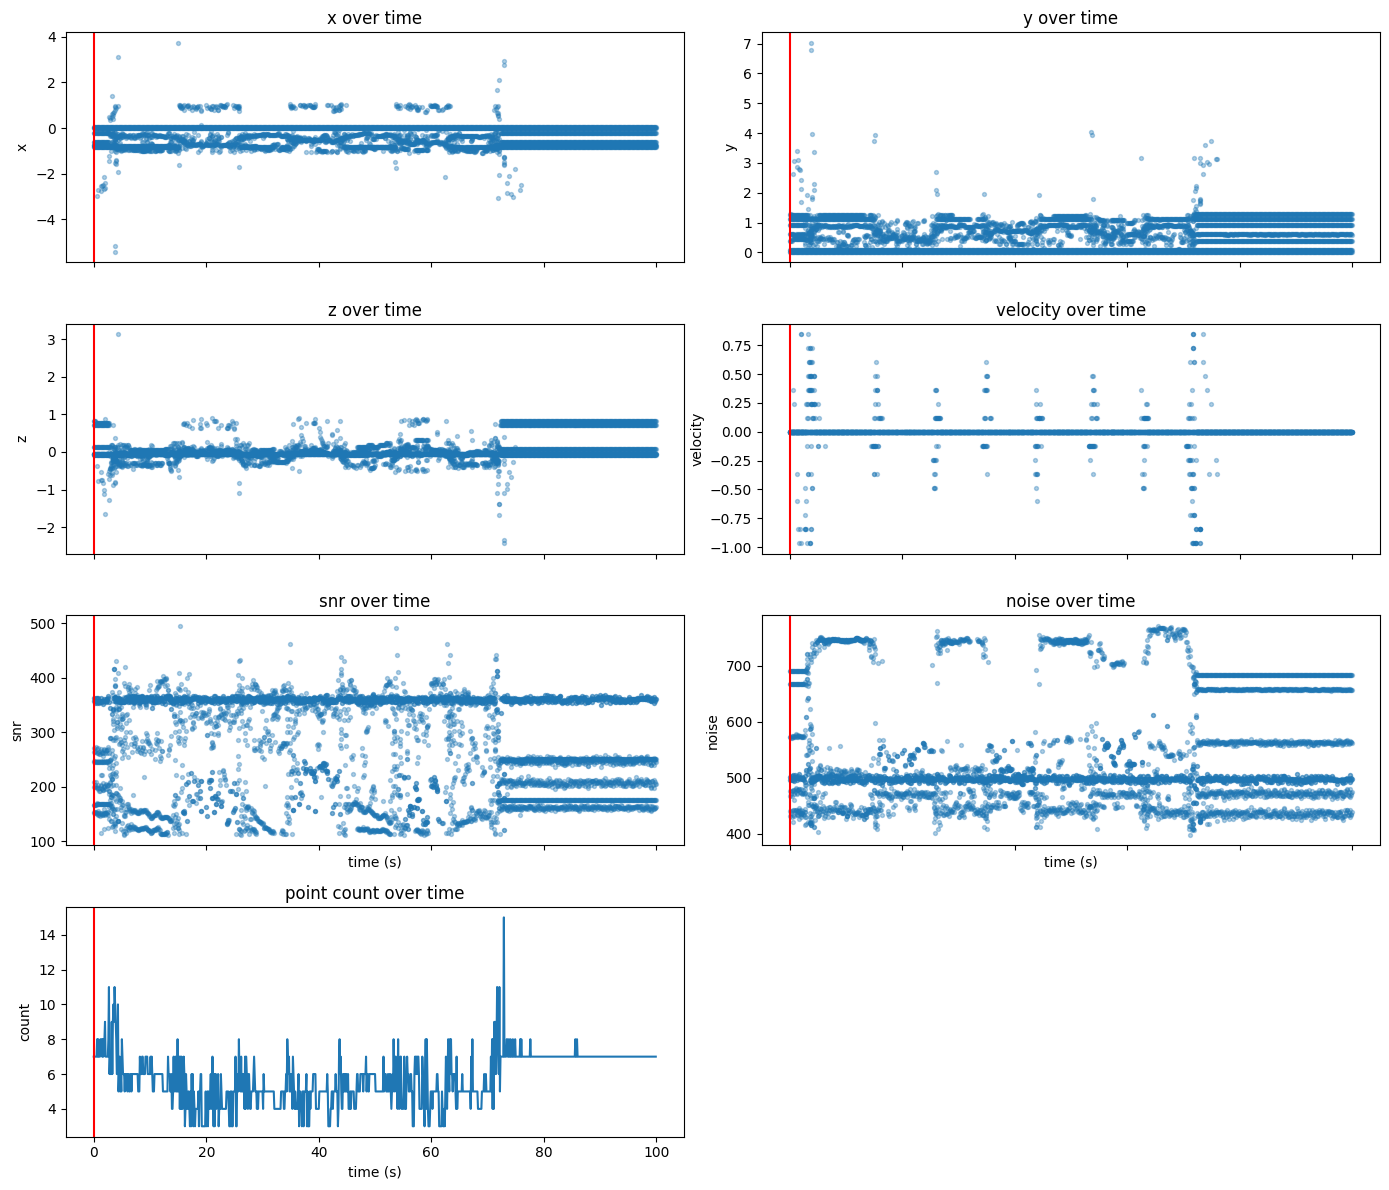

In [63]:
plot_feature_time(frames, FPS, T)

In [64]:
def plot_x_time(frames, fps, t, intervals):
    times, values = get_feature_time_values(frames, "x", fps)
    frame_times = get_frame_times(frames, fps)
    mean_values = get_feature_means(frames, "x")
    selected_time = t / fps
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.scatter(times, values, s=10, alpha=0.25, color="tab:blue")
    ax.plot(frame_times, mean_values, color="black", linewidth=2)
    for start, end, label in intervals:
        ax.axvspan(start, end, color="tab:orange", alpha=0.18)
        ax.text((start + end) / 2, ax.get_ylim()[1], label, ha="center", va="bottom")
    ax.axvline(selected_time, color="red")
    ax.set_title("x over time")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("x")
    fig.tight_layout()

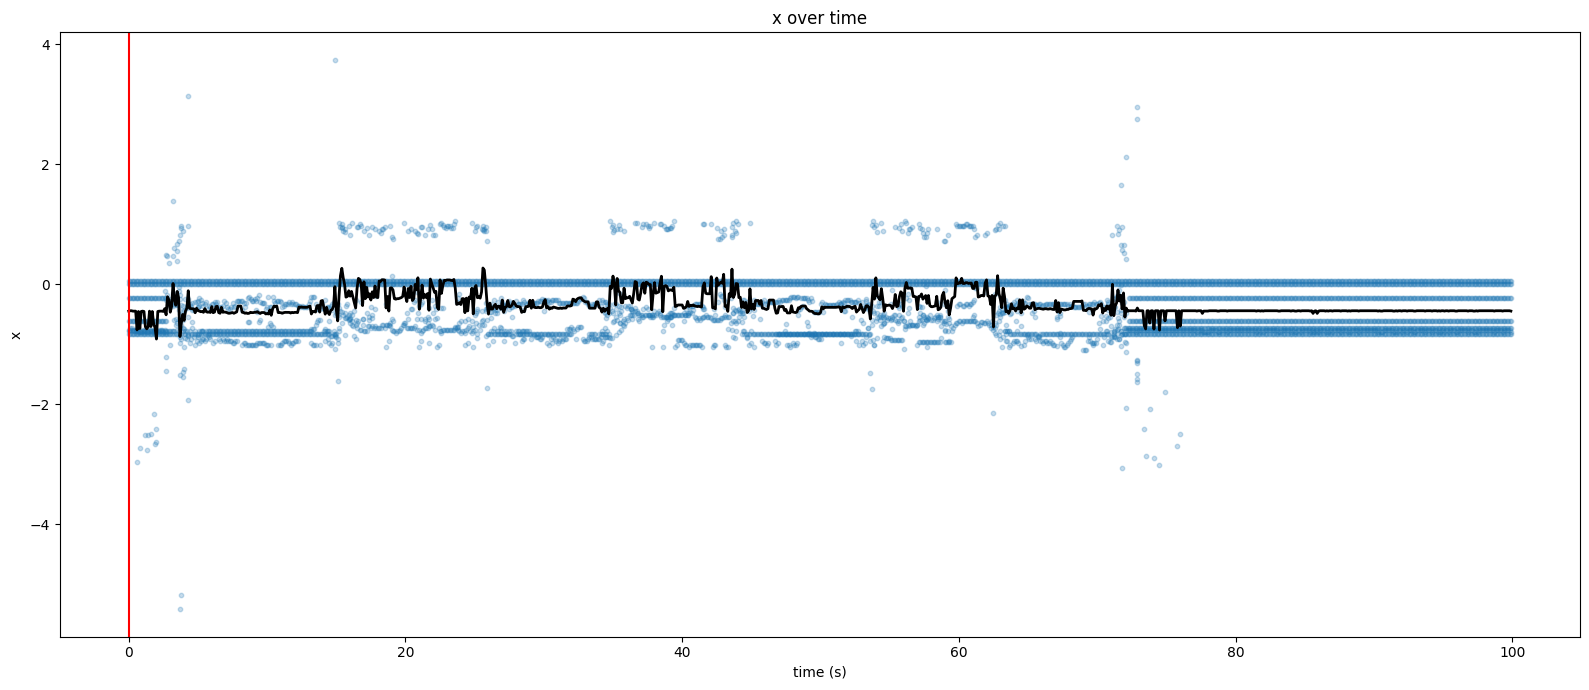

In [65]:
plot_x_time(frames, FPS, T, LABEL_INTERVALS)

In [66]:
def get_label(time_s, intervals):
    for start, end, label in intervals:
        if start <= time_s < end:
            return label
    return "unlabeled"

In [67]:
def add_labels(frames, fps, intervals):
    labeled_frames = []
    for index, frame in enumerate(frames):
        time_s = index / fps
        labeled_frames.append(
            {
                "frame_number": frame["frame_number"],
                "time_s": time_s,
                "label": get_label(time_s, intervals),
                "points": frame["points"],
            }
        )
    return labeled_frames

In [68]:
labeled_frames = add_labels(frames, FPS, LABEL_INTERVALS)
print(labeled_frames[0]["label"], labeled_frames[T]["label"], labeled_frames[-1]["label"])

unlabeled unlabeled unlabeled


In [69]:
def save_labeled_frames(path, labeled_frames):
    path.write_text(json.dumps({"frames": labeled_frames}, indent=2))

In [70]:
save_labeled_frames(LABELED_PATH, labeled_frames)
print(LABELED_PATH)

record2.labeled.json
